# Deterministic FlexiTokens vocabularies on FLORES

This is the canonical report for the six-language FLORES analysis. It replaces the earlier seed-based and whitespace-split analysis.

## Method

- Each original FLORES sentence is tokenized as one complete input.
- No seeds or random boundary samples are used.
- A boundary is placed exactly when `sigmoid(boundary_logit) > 0.5`.
- The vocabulary is the counted set of unique decoded output segments across all complete-sentence tokenizations.
- Every vocabulary entry includes up to three source-sentence examples for manual inspection.

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import SVG, display

RESULT_CANDIDATES = [
    Path('results/deterministic_sentence_segment_vocabulary_full_v2'),
    Path('flexitokens/results/deterministic_sentence_segment_vocabulary_full_v2'),
]
RESULTS = next((path for path in RESULT_CANDIDATES if (path / 'summary.csv').is_file()), None)
if RESULTS is None:
    raise FileNotFoundError('Run this notebook from the repository root or the flexitokens folder.')
metadata = json.loads((RESULTS / 'run_metadata.json').read_text())
assert metadata['boundary_rule'] == 'sigmoid(boundary_logit) > 0.5'
assert metadata['randomness'] == 'none; Gumbel sampling is explicitly disabled for this evaluation'
summary = pd.read_csv(RESULTS / 'summary.csv')
assert (summary['sentences'] == 2009).all()
summary[['language', 'sentences', 'unique_output_segments_vocabulary_size', 'total_output_segment_occurrences', 'mean_segments_per_sentence']]

,language,sentences,unique_output_segments_vocabulary_size,total_output_segment_occurrences,mean_segments_per_sentence
0,en,2009,9895,76373,38.015431
1,es,2009,11741,75943,37.801394
2,ru,2009,12137,76948,38.301643
3,uk,2009,10980,77605,38.628671
4,hi,2009,8146,75145,37.404181
5,te,2009,10695,75913,37.786461


## Summary charts

These descriptive charts are generated from the completed result CSVs. They describe the observed corpus output and do not measure downstream model quality.

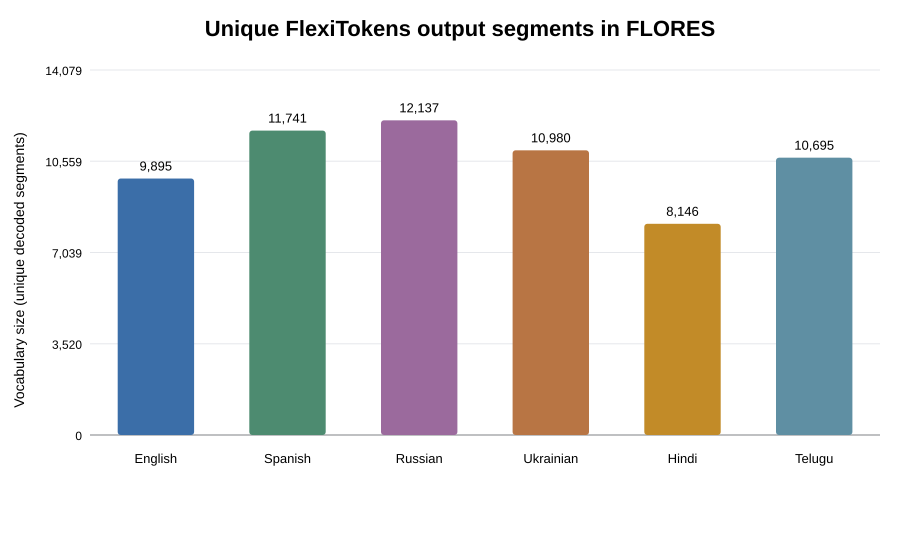

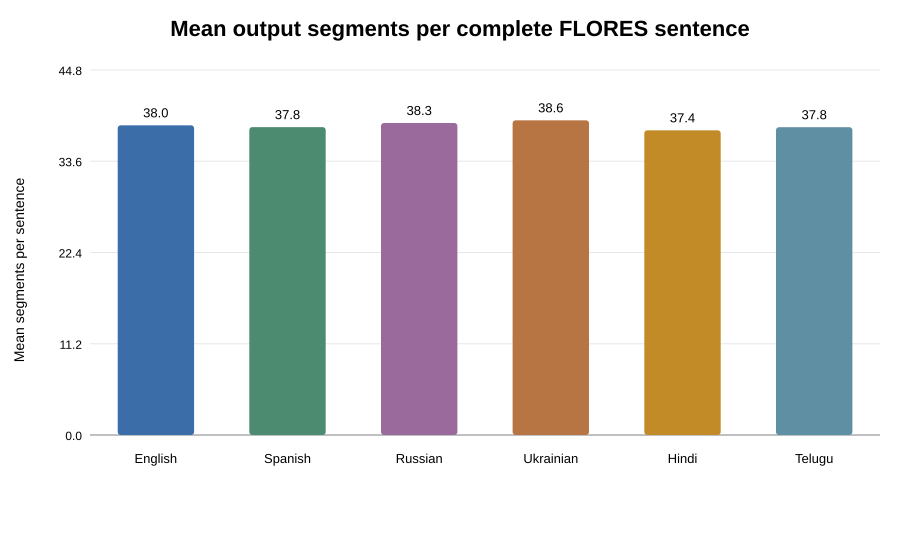

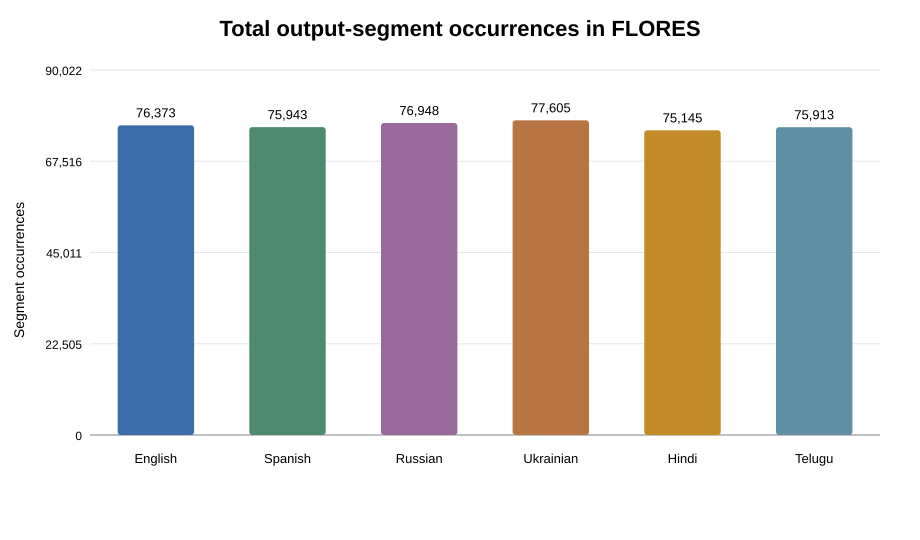

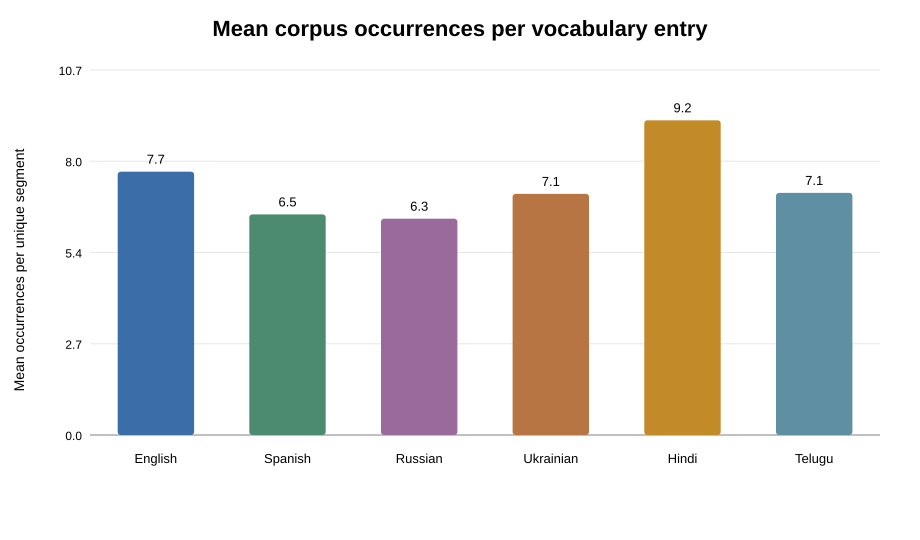

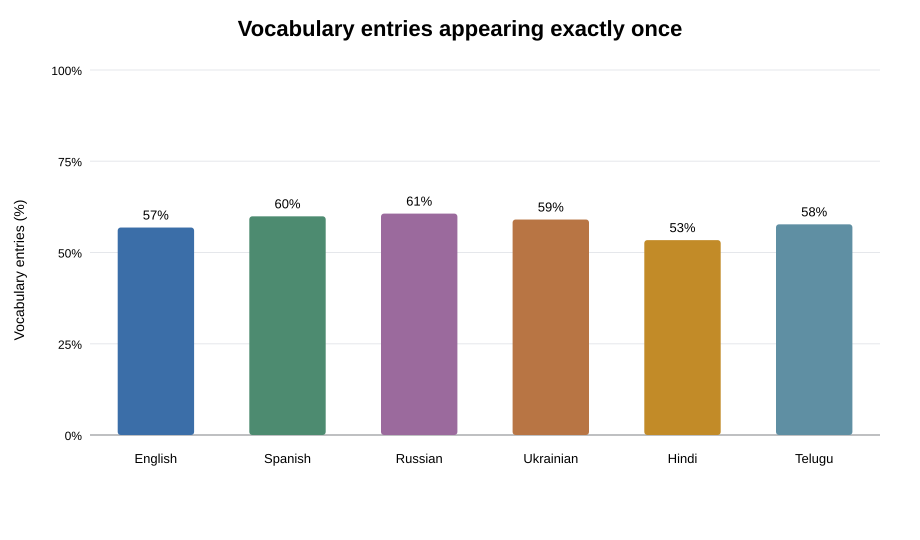

In [ ]:
for chart in [
    'vocabulary_size_by_language.svg',
    'mean_segments_per_sentence.svg',
    'total_segment_occurrences_by_language.svg',
    'mean_occurrences_per_vocabulary_entry.svg',
    'singleton_vocabulary_entries.svg',
]:
    display(SVG(filename=RESULTS / 'figures' / chart))

## Manual inspection examples

The following are actual stored full-sentence segmentations. Spaces and punctuation shown inside a segment are part of that decoded segment.

In [ ]:
english = pd.read_csv(RESULTS / 'en_sentence_tokenizations.csv')
english.loc[english['text'].str.contains('invention', regex=False), ['text', 'segments', 'segment_count']].head(1)

,text,segments,segment_count
0,"On Monday, scientists from the Stanford Univer...","[""On"","" "",""Mon"",""day, "",""sci en t"",""ist"",""s "",...",82


In [ ]:
for language in ['en', 'es', 'ru', 'uk', 'hi', 'te']:
    vocabulary = pd.read_csv(RESULTS / f'{language}_segment_vocabulary.csv')
    print(f'\n{language}: {len(vocabulary):,} unique output segments')
    display(vocabulary[['segment_display', 'count', 'example_occurrences']].head(5))


en: 9,895 unique output segments


,segment_display,count,example_occurrences
0,'t',6334,"[{""sentence_id"": 0, ""text"": ""On Monday, scient..."
1,' ',5988,"[{""sentence_id"": 0, ""text"": ""On Monday, scient..."
2,'he ',3045,"[{""sentence_id"": 0, ""text"": ""On Monday, scient..."
3,'of ',1279,"[{""sentence_id"": 0, ""text"": ""On Monday, scient..."
4,'o ',1254,"[{""sentence_id"": 1, ""text"": ""Lead researchers ..."



es: 11,741 unique output segments


,segment_display,count,example_occurrences
0,'de ',3631,"[{""sentence_id"": 0, ""text"": ""El lunes, los cie..."
1,' ',2267,"[{""sentence_id"": 0, ""text"": ""El lunes, los cie..."
2,'a ',2132,"[{""sentence_id"": 0, ""text"": ""El lunes, los cie..."
3,'la ',1600,"[{""sentence_id"": 0, ""text"": ""El lunes, los cie..."
4,'en ',1498,"[{""sentence_id"": 1, ""text"": ""Los principales i..."



ru: 12,137 unique output segments


...

,segment_display,count,example_occurrences
0,' ',2576,"[{""sentence_id"": 0, ""text"": ""У понеділок, наук..."
1,'і ',1889,"[{""sentence_id"": 1, ""text"": ""Провідні дослідни..."
2,'',1338,"[{""sentence_id"": 0, ""text"": ""У понеділок, наук..."
3,'у ',1200,"[{""sentence_id"": 1, ""text"": ""Провідні дослідни..."
4,'и ',1059,"[{""sentence_id"": 0, ""text"": ""У понеділок, наук..."



hi: 8,146 unique output segments


,segment_display,count,example_occurrences
0,' ',5184,"[{""sentence_id"": 0, ""text"": ""सोमवार को, स्टैनफ..."
1,'के ',2284,"[{""sentence_id"": 0, ""text"": ""सोमवार को, स्टैनफ..."
2,'में ',1529,"[{""sentence_id"": 1, ""text"": ""शोधकर्ताओं ने कहा..."
3,'की ',1125,"[{""sentence_id"": 0, ""text"": ""सोमवार को, स्टैनफ..."
4,'और ',1121,"[{""sentence_id"": 1, ""text"": ""शोधकर्ताओं ने कहा..."



te: 10,695 unique output segments


,segment_display,count,example_occurrences
0,' ',11945,"[{""sentence_id"": 0, ""text"": ""సోమవారం, స్టాన్ఫో..."
1,'.',1032,"[{""sentence_id"": 3, ""text"": ""పైలట్‌ను స్క్వాడ్..."
2,"', '",1022,"[{""sentence_id"": 1, ""text"": ""ఇది తక్కువ ఆదాయం ..."
3,'',925,"[{""sentence_id"": 0, ""text"": ""సోమవారం, స్టాన్ఫో..."
4,'క',917,"[{""sentence_id"": 3, ""text"": ""పైలట్‌ను స్క్వాడ్..."


## Files

- `summary.csv`: per-language totals.
- `*_segment_vocabulary.csv`: every unique segment, its count, and source examples.
- `*_sentence_tokenizations.csv`: the complete sentence tokenizations used to build the vocabularies.
- `README.md`: method, result table, and interpretation boundaries.